In [24]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera

# Ejercicio

Con las siguientes masas y condiciones iniciales:

- Masas: s = 1, e = 0.5, L = 0.001, p = 0.01.

- Condiciones iniciales: a continuación se proveen datos del vector y velocidad relativa para cada subsistema:

   - Sistema p-L: $\vec r :(0.03,0,0), \vec v : (0,0.4,0.1)$

   - Sistema e-pL (baricentro de p y L): $\vec r :(0,0.4,0), \vec v : (0.9,0,0.2)$
     
  - Sistema s-epL (baricentro e y pL): $\vec r :(2,3,0), \vec v : (-0.2,0.7,0)$

The relations tree is as follows:

```text
S
├── A (sub)
│   ├── B (subsub)
│   │    ├── p (planet)
│   │    ├── l (moon)
│   └── e (lil star)
└── s (big star)
```

In [25]:
# Cannonical units
G = 1

In [ ]:
# We start by defining the masses:

mass_s = 1
mass_e = 0.5
mass_l = 0.001
mass_p = 0.01

In [27]:
# We define the positions for each system:

# System B (p-l)
mass_B = mass_p + mass_l
r_B = np.array([0.03, 0.0, 0.0])
v_B = np.array([0.0, 0.4, 0.1])

# System A (B + e)
mass_A = mass_B + mass_e
r_A = np.array([0.0, 0.4, 0.0])
v_A = np.array([0.9, 0.0, 0.2])

# System S (A + s)
mass_S = mass_A + mass_s
r_S = np.array([2.0, 3.0, 0.0])
v_S = np.array([-0.2, 0.7, 0.0])

In [28]:
# We define the center of mass for the big system:

RCM_S = np.array([0.0, 0.0, 0.0])
VCM_S = np.array([0.0, 0.0, 0.0])

In [29]:
# We begin going down the hierarchy, starting with the biggest system:

# System S (system A is particle 1, star s is particle 2):

# A to 1
RCM_A = RCM_S + mass_s / (mass_A + mass_s) * r_S
VCM_A = VCM_S + mass_s / (mass_A + mass_s) * v_S

# S to 2
r_s = RCM_S  - mass_A / (mass_A + mass_s) * r_S
v_s = VCM_S  - mass_A / (mass_A + mass_s) * v_S

RCM_A, VCM_A, r_s, v_s

(array([1.32362674, 1.98544011, 0.        ]),
 array([-0.13236267,  0.46326936,  0.        ]),
 array([-0.67637326, -1.01455989,  0.        ]),
 array([ 0.06763733, -0.23673064,  0.        ]))

In [30]:
# Branch A (system B is particle 1, star e is particle 2):

# B to 1
RCM_B = RCM_A + mass_e / (mass_B + mass_e) * r_A
VCM_B = VCM_A + mass_e / (mass_B + mass_e) * v_A

# e to 2
r_e = RCM_A - mass_B / (mass_B + mass_e) * r_A
v_e = VCM_A - mass_B / (mass_B + mass_e) * v_A

RCM_B, VCM_B, r_e, v_e

(array([1.32362674, 2.37682954, 0.        ]),
 array([0.74826355, 0.46326936, 0.19569472]),
 array([1.32362674, 1.97682954, 0.        ]),
 array([-0.15173645,  0.46326936, -0.00430528]))

In [37]:
# Branch B (planet is particle 1, moon l is particle 2):

# p to 1
r_p = RCM_B + mass_l / (mass_p + mass_l) * r_B
v_p = VCM_B + mass_l / (mass_p + mass_l) * v_B

# l to 2
r_l = RCM_B - mass_p / (mass_p + mass_l) * r_B
v_l = VCM_B - mass_p / (mass_p + mass_l) * v_B

r_p, v_p, r_l, v_l

(array([1.32635401, 2.37682954, 0.        ]),
 array([0.74826355, 0.49963299, 0.20478563]),
 array([1.29635401, 2.37682954, 0.        ]),
 array([0.74826355, 0.09963299, 0.10478563]))

### System Simulation 

In [44]:
system = [
    dict(m = mass_s, r = r_s, v = v_s),
    dict(m = mass_e, r = r_e, v = v_e), 
    dict(m = mass_p, r = r_p, v = v_p),
    dict(m = mass_l, r = r_l, v = v_l)
]

ts = np.linspace(0, 100, 1000)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(system, ts)

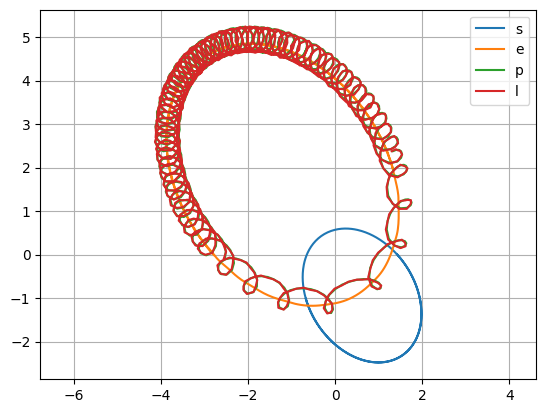

In [45]:
plt.plot(rps[0, :, 0], rps[0, :, 1], '-', label='s')
plt.plot(rps[1, :, 0], rps[1, :, 1], '-', label='e')
plt.plot(rps[2, :, 0], rps[2, :, 1], '-', label='p')
plt.plot(rps[3, :, 0], rps[3, :, 1], '-', label='l')
plt.legend()
plt.axis('equal')
plt.grid()

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))
camera = Camera(fig)

# Fondo del grafico (una sola vez).
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.3)

# Menos cuadros => render mas rapido.
step = 10

for i in range(0, len(ts), step):
    ax.plot(rps[0, :, 0], rps[0, :, 1], 'k-', lw=1, alpha=0.25, label='s')
    ax.plot(rps[1, :, 0], rps[1, :, 1], 'k-', lw=1, alpha=0.25, label='e')
    ax.plot(rps[2, :, 0], rps[2, :, 1], 'k-', lw=1, alpha=0.25, label='p')
    ax.plot(rps[3, :, 0], rps[3, :, 1], 'k-', lw=1, alpha=0.25, label='l')
    ax.plot(rps[0, i, 0], rps[0, i, 1], 'ro', ms=7)
    ax.plot(rps[1, i, 0], rps[1, i, 1], 'bo', ms=5)
    ax.plot(rps[2, i, 0], rps[2, i, 1], 'ko', ms=6)
    ax.plot(rps[3, i, 0], rps[3, i, 1], 'yo', ms=8)
    camera.snap()

anim = camera.animate(interval=60, blit=False)
plt.close(fig)

from IPython.display import HTML
HTML(anim.to_jshtml())

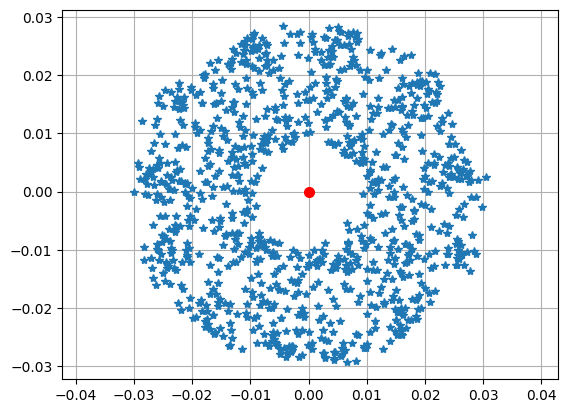

In [56]:
# Graph of the moon's trajectory in the frame of the planet:

r_l_p = rps[3, :, :] - rps[2, :, :]

plt.plot(r_l_p[:, 0], r_l_p[:, 1], '*')
plt.plot(0, 0, 'ro', ms=7)
plt.axis('equal')
plt.grid()